# Analyse Exploratoire

### Import des modules

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### Analyse Exploratoire

In [137]:
PATH = 'C:\\Users\\paule\\Documents\\OpenCR\\Projet 6 - ML Batiment\\opc_batimentML\\data\\2016_Building_Energy_Benchmarking.csv'

In [138]:
building_consumption = pd.read_csv(PATH)

In [139]:
# nombre de ligne et colonne avant nettoyage
building_consumption.shape

(3376, 46)

In [140]:
# On regarde comment un batiment est défini dans ce jeu de données 
pd.set_option('display.max_columns', None)
building_consumption.head(5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [141]:
building_consumption.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [142]:
building_consumption[['BuildingType', 'PrimaryPropertyType','Neighborhood','YearBuilt','NumberofBuildings',
       'NumberofFloors','PropertyGFATotal','TotalGHGEmissions']]

,BuildingType,PrimaryPropertyType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,TotalGHGEmissions
0,NonResidential,Hotel,DOWNTOWN,1927,1.0,12,88434,249.98
1,NonResidential,Hotel,DOWNTOWN,1996,1.0,11,103566,295.86
2,NonResidential,Hotel,DOWNTOWN,1969,1.0,41,956110,2089.28
3,NonResidential,Hotel,DOWNTOWN,1926,1.0,10,61320,286.43
4,NonResidential,Hotel,DOWNTOWN,1980,1.0,18,175580,505.01
...,...,...,...,...,...,...,...,...
3371,Nonresidential COS,Office,GREATER DUWAMISH,1990,1.0,1,12294,20.94
3372,Nonresidential COS,Other,DOWNTOWN,2004,1.0,1,16000,32.17
3373,Nonresidential COS,Other,MAGNOLIA / QUEEN ANNE,1974,1.0,1,13157,223.54
3374,Nonresidential COS,Mixed Use Property,GREATER DUWAMISH,1989,1.0,1,14101,22.11


In [143]:
#Nettoyage
#on garde les batiments ayant default data == false
building_consumption = building_consumption[building_consumption['DefaultData'] == False]

#on supprime les batiments ayant Compliance status = missing data ou Error
bad_compliance_status = ['Error - Correct Default Data','Missing Data']
building_consumption = building_consumption[~building_consumption['ComplianceStatus'].isin(bad_compliance_status)]

In [144]:
building_consumption['BuildingType'].value_counts()

BuildingType
NonResidential          1449
Multifamily LR (1-4)    1001
Multifamily MR (5-9)     572
Multifamily HR (10+)     109
Nonresidential COS        82
Campus                    24
SPS-District K-12         10
Nonresidential WA          1
Name: count, dtype: int64

In [145]:
# On garde uniquement les types de batiments non - résidentiels
building_type_to_remove = ['Multifamily LR (1-4)', 'Multifamily MR (5-9)', 'Multifamily HR (10+)']
building_consumption = building_consumption[~building_consumption['BuildingType'].isin(building_type_to_remove)]

In [146]:
building_consumption.shape

(1566, 46)

In [147]:
# On enleve les colonnes non pertinentes pour notre analyse
columns_to_remove = ['OSEBuildingID','DataYear', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Latitude', 'Longitude','Comments','DefaultData','YearsENERGYSTARCertified','PrimaryPropertyType']
building_consumption = building_consumption.drop(columns=columns_to_remove)

In [148]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1566 entries, 0 to 3375
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1566 non-null   object 
 1   Neighborhood                     1566 non-null   object 
 2   YearBuilt                        1566 non-null   int64  
 3   NumberofBuildings                1564 non-null   float64
 4   NumberofFloors                   1566 non-null   int64  
 5   PropertyGFATotal                 1566 non-null   int64  
 6   PropertyGFAParking               1566 non-null   int64  
 7   PropertyGFABuilding(s)           1566 non-null   int64  
 8   ListOfAllPropertyUseTypes        1564 non-null   object 
 9   LargestPropertyUseType           1560 non-null   object 
 10  LargestPropertyUseTypeGFA        1560 non-null   float64
 11  SecondLargestPropertyUseType     849 non-null    object 
 12  SecondLargestPropertyUseT

colonne target = TotalGHG Emissions

In [149]:
#handle null/nan values
building_consumption = building_consumption.dropna(subset=['TotalGHGEmissions'])
building_consumption = building_consumption.dropna(subset=['Electricity(kWh)'])
building_consumption = building_consumption.dropna(subset=['LargestPropertyUseType'])
building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].fillna(0)
building_consumption['Outlier'] = building_consumption['Outlier'].fillna('')

In [150]:
#valeurs aberantes (energie négative ou égale à Zero)
building_consumption = building_consumption[building_consumption['TotalGHGEmissions'] >= 0]
building_consumption = building_consumption[building_consumption['Electricity(kWh)'] > 0]
building_consumption = building_consumption[building_consumption['SiteEnergyUseWN(kBtu)'] > 0]
building_consumption = building_consumption[building_consumption['SourceEUI(kBtu/sf)'] > 0]

In [151]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 3375
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1545 non-null   object 
 1   Neighborhood                     1545 non-null   object 
 2   YearBuilt                        1545 non-null   int64  
 3   NumberofBuildings                1545 non-null   float64
 4   NumberofFloors                   1545 non-null   int64  
 5   PropertyGFATotal                 1545 non-null   int64  
 6   PropertyGFAParking               1545 non-null   int64  
 7   PropertyGFABuilding(s)           1545 non-null   int64  
 8   ListOfAllPropertyUseTypes        1545 non-null   object 
 9   LargestPropertyUseType           1545 non-null   object 
 10  LargestPropertyUseTypeGFA        1545 non-null   float64
 11  SecondLargestPropertyUseType     842 non-null    object 
 12  SecondLargestPropertyUseT

In [152]:
#analyse des données non numériques
categorical_columns = building_consumption.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"Valeurs uniques dans la colonne {col}:")
    print(building_consumption[col].value_counts())
    print("\n")

Valeurs uniques dans la colonne BuildingType:
BuildingType
NonResidential        1429
Nonresidential COS      82
Campus                  23
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64


Valeurs uniques dans la colonne Neighborhood:
Neighborhood
DOWNTOWN                  348
GREATER DUWAMISH          331
MAGNOLIA / QUEEN ANNE     143
LAKE UNION                142
EAST                      117
NORTHEAST                 115
NORTHWEST                  74
BALLARD                    57
NORTH                      51
CENTRAL                    43
DELRIDGE                   36
SOUTHWEST                  32
SOUTHEAST                  31
North                       8
Ballard                     5
Delridge                    4
Central                     4
Northwest                   3
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64


Valeurs uniques dans la colonne ListOfAllPropertyUseTypes:
ListOfAllPropertyUseTypes
Office                              

In [153]:
#analyse des données numériques
numerical_columns = building_consumption.select_dtypes(include=['number']).columns
building_consumption[numerical_columns].describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1545.000000,1545.000000,1545.00000,1.545000e+03,1545.000000,1.545000e+03,1.545000e+03,842.000000,347.000000,995.000000,1545.000000,1545.000000,1545.000000,1545.000000,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1545.000000,1545.000000
mean,1961.433010,1.110032,4.24466,1.148078e+05,13711.491262,1.010963e+05,9.342637e+04,36137.917217,15054.444953,63.768844,74.686473,77.590485,183.106084,186.538058,8.257427e+06,8.478240e+06,4.883333e+05,1.673900e+06,5.711348e+06,2.032438e+04,2.032438e+06,185.452324,1.655806
std,32.896479,1.203216,6.76117,1.975686e+05,43610.856555,1.752811e+05,1.622233e+05,66583.782733,37091.254288,29.004697,75.555297,76.486355,190.198503,189.971024,2.228408e+07,2.281152e+07,5.298159e+06,4.034371e+06,1.376527e+07,9.717086e+04,9.717086e+06,728.111111,2.391250
min,1900.000000,0.000000,0.00000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.700000,0.700000,2.100000,2.200000,1.680890e+04,1.726000e+04,0.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.120000,0.000000
25%,1930.000000,1.000000,1.00000,2.880000e+04,0.000000,2.780000e+04,2.498800e+04,5325.000000,2613.500000,44.000000,34.400002,37.000000,79.599998,84.300003,1.232823e+06,1.316901e+06,0.000000e+00,2.120948e+05,7.236670e+05,0.000000e+00,0.000000e+00,20.090000,0.350000
50%,1965.000000,1.000000,2.00000,4.796300e+04,0.000000,4.586400e+04,4.163200e+04,11999.500000,6000.000000,71.000000,53.599998,56.299999,138.100006,141.800003,2.662054e+06,2.810298e+06,0.000000e+00,4.953024e+05,1.689972e+06,4.809920e+03,4.809920e+05,49.580000,0.880000
75%,1988.000000,1.000000,4.00000,1.060000e+05,0.000000,9.471300e+04,9.153200e+04,31820.250000,12990.000000,89.000000,84.699997,87.900002,211.800003,215.899994,7.265178e+06,7.536508e+06,0.000000e+00,1.539311e+06,5.252130e+06,1.530688e+04,1.530688e+06,145.480000,1.960000
max,2015.000000,27.000000,99.00000,2.200000e+06,512608.000000,2.200000e+06,1.719643e+06,639931.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,4.483853e+08,4.716139e+08,1.349435e+08,8.046087e+07,2.745325e+08,2.979090e+06,2.979090e+08,16870.980000,34.090000


In [154]:
#number of building = 0 and number of floor >  0 : erreur / données manquantes 
building_consumption[(building_consumption['NumberofBuildings'] == 0) & (building_consumption['NumberofFloors'] > 0)].head(5)

,BuildingType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
63,NonResidential,EAST,1965,0.0,3,179014,0,179014,Medical Office,Medical Office,179014.0,NaN,NaN,NaN,NaN,48.0,93.300003,92.300003,213.399994,210.300003,16701055.00,16527711.00,0.0,2.897563e+06,9886484.0,68145.70313,6814570.0,Compliant,,430.84,2.41
76,NonResidential,MAGNOLIA / QUEEN ANNE,1986,0.0,2,66240,2352,63888,"Data Center, Distribution Center, Office, Park...",Office,45900.0,Data Center,5181.0,Distribution Center,4551.0,NaN,74.900002,75.400002,235.199997,236.600006,4166306.25,4192107.75,0.0,1.221074e+06,4166305.0,0.00000,0.0,Compliant,,29.04,0.44
160,NonResidential,GREATER DUWAMISH,1916,0.0,4,79600,0,79600,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,79600.0,NaN,NaN,NaN,NaN,34.0,30.299999,30.299999,95.099998,95.099998,2411402.25,2411402.25,0.0,7.067415e+05,2411402.0,0.00000,0.0,Compliant,,16.81,0.21
201,NonResidential,DOWNTOWN,1968,0.0,3,100734,26731,74003,Office,Office,100734.0,NaN,NaN,NaN,NaN,20.0,97.199997,98.199997,305.100006,308.399994,9788717.00,9892566.00,0.0,2.868908e+06,9788716.0,0.00000,0.0,Compliant,,68.24,0.68
241,NonResidential,NORTHEAST,1961,0.0,5,99005,0,99005,Office,Office,79555.0,NaN,NaN,NaN,NaN,70.0,59.400002,63.000000,137.600006,140.699997,4728488.50,5008123.50,0.0,8.391593e+05,2863212.0,18652.76563,1865277.0,Compliant,,119.03,1.20


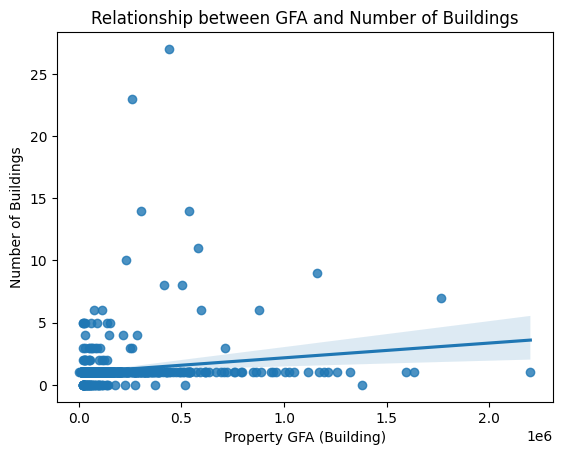

In [155]:
#analyse relation nbre batiment / property GFA builing
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x='PropertyGFABuilding(s)',
    y='NumberofBuildings',
    data=building_consumption
)

plt.xlabel('Property GFA (Building)')
plt.ylabel('Number of Buildings')
plt.title('Relationship between GFA and Number of Buildings')

plt.show()


In [156]:
import numpy as np
from sklearn.linear_model import LinearRegression
# les batiments ayant number floor > 0 et nombre de batiment =0 sont invalides, on créer une régression linéaire pour remplacer les valeurs des batiments invalides


# 1) Identifier les batiments valides et invalides
valid = (
    (building_consumption['NumberofBuildings'] > 0) |
    ((building_consumption['NumberofBuildings'] == 0) &
     (building_consumption['NumberofFloors'] == 0))
)

invalid = (
    (building_consumption['NumberofBuildings'] == 0) &
    (building_consumption['NumberofFloors'] > 0)
)

# 2) On entraine les données avec la surface du batiments, nombre étages et années de construction
X_valid = building_consumption.loc[valid, [
    'PropertyGFABuilding(s)', 'NumberofFloors', 'YearBuilt'
]]
y_valid = building_consumption.loc[valid, 'NumberofBuildings']

# 3) Train model
model = LinearRegression()
model.fit(X_valid, y_valid)

# 4) Predict missing NumberofBuildings only if such rows exist
if invalid.any():
    X_invalid = building_consumption.loc[invalid, [
        'PropertyGFABuilding(s)', 'NumberofFloors', 'YearBuilt'
    ]]
    
    predicted = model.predict(X_invalid)

    # minimum 1 building
    predicted = np.maximum(1, np.round(predicted))

    building_consumption.loc[invalid, 'NumberofBuildings'] = predicted


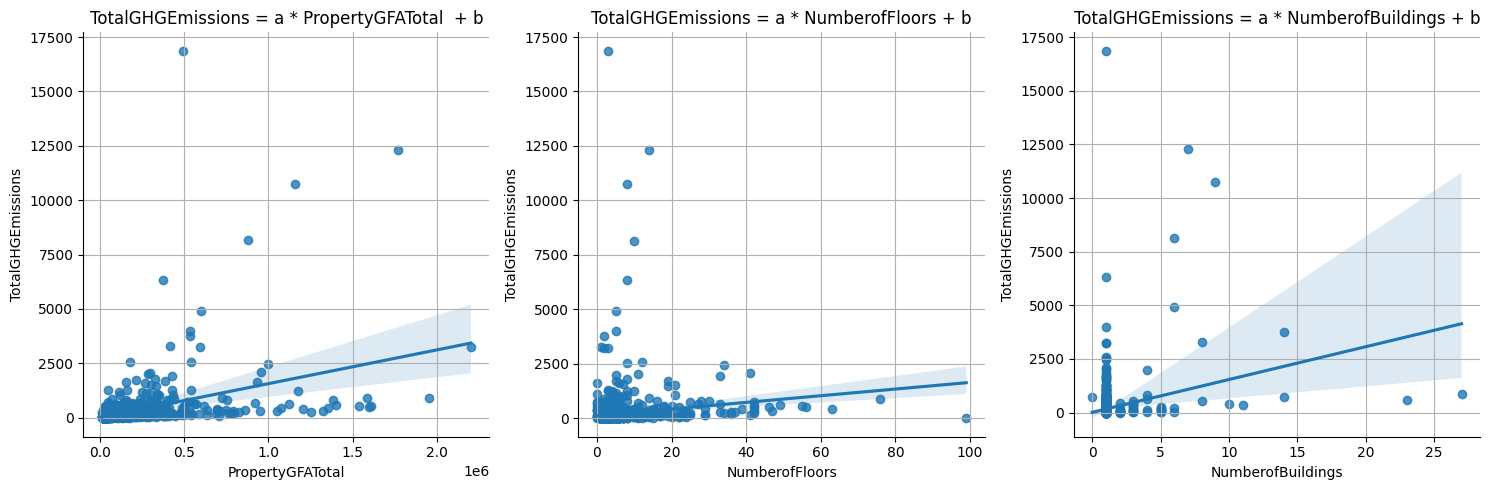

In [157]:
#relation TotalGHGEmissions et Surface, nbre batiment, nbre étage
fig, ax = plt.subplots(1,3, figsize = (15,5))

plt.subplot(1,3,1)
sns.regplot(x = building_consumption[['PropertyGFATotal']],y  =  building_consumption.TotalGHGEmissions)
plt.ylabel('TotalGHGEmissions')
plt.xlabel('PropertyGFATotal')
plt.title('TotalGHGEmissions = a * PropertyGFATotal  + b')
plt.grid()
sns.despine()

plt.subplot(1,3,2)
sns.regplot(x = building_consumption[['NumberofFloors']],y  =  building_consumption.TotalGHGEmissions)
plt.ylabel('TotalGHGEmissions')
plt.xlabel('NumberofFloors')
plt.title('TotalGHGEmissions = a * NumberofFloors + b')
plt.grid()
sns.despine()

plt.subplot(1,3,3)
res = sns.regplot(x = building_consumption[['NumberofBuildings']],y  =  building_consumption.TotalGHGEmissions)
plt.ylabel('TotalGHGEmissions')
plt.xlabel('NumberofBuildings')
plt.title('TotalGHGEmissions = a * NumberofBuildings + b')
plt.grid()
sns.despine()

plt.tight_layout()
plt.show()

In [158]:
building_consumption[numerical_columns].corr()['TotalGHGEmissions']

YearBuilt                          0.077564
NumberofBuildings                  0.249766
NumberofFloors                     0.141986
PropertyGFATotal                   0.421986
PropertyGFAParking                 0.061562
PropertyGFABuilding(s)             0.460326
LargestPropertyUseTypeGFA          0.529750
SecondLargestPropertyUseTypeGFA    0.539050
ThirdLargestPropertyUseTypeGFA     0.693762
ENERGYSTARScore                   -0.103618
SiteEUI(kBtu/sf)                   0.270820
SiteEUIWN(kBtu/sf)                 0.270345
SourceEUI(kBtu/sf)                 0.211285
SourceEUIWN(kBtu/sf)               0.209722
SiteEnergyUse(kBtu)                0.917101
SiteEnergyUseWN(kBtu)              0.920970
SteamUse(kBtu)                     0.635021
Electricity(kWh)                   0.689940
Electricity(kBtu)                  0.689940
NaturalGas(therms)                 0.779360
NaturalGas(kBtu)                   0.779360
TotalGHGEmissions                  1.000000
GHGEmissionsIntensity           

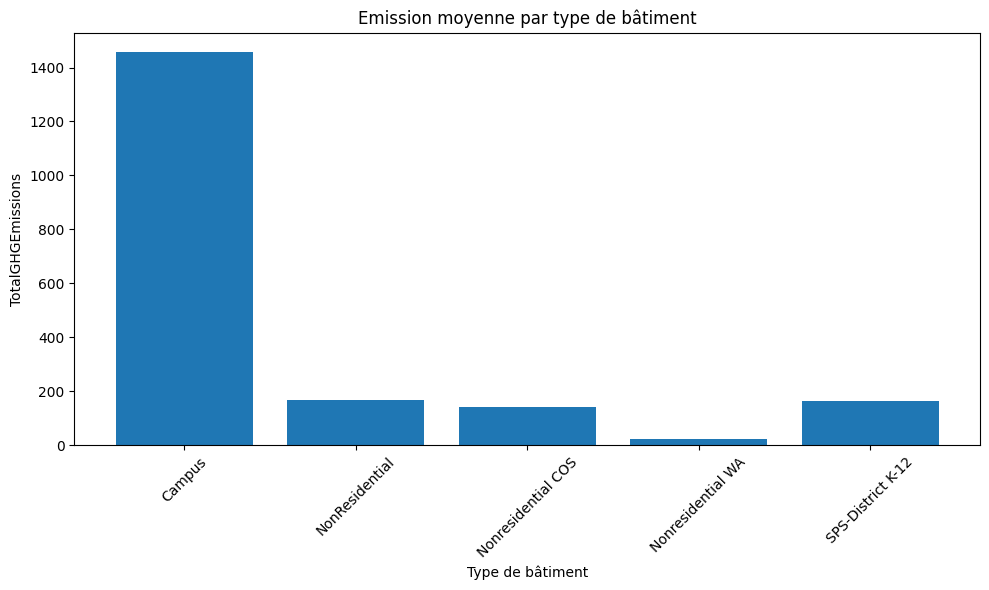

In [159]:
# Moyennes Emission par types de batiements 
moyennes = building_consumption.groupby("BuildingType")["TotalGHGEmissions"].mean()

plt.figure(figsize=(10, 6))

plt.bar(moyennes.index, moyennes.values)
plt.xlabel("Type de bâtiment")
plt.ylabel("TotalGHGEmissions")
plt.title("Emission moyenne par type de bâtiment")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

# Modélisation 

### Import des modules 

In [160]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [161]:
building_consumption.head(5)

,BuildingType,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,NonResidential,DOWNTOWN,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,Compliant,,249.98,2.83
1,NonResidential,DOWNTOWN,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,Compliant,,295.86,2.86
2,NonResidential,DOWNTOWN,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,Compliant,,2089.28,2.19
3,NonResidential,DOWNTOWN,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,Compliant,,286.43,4.67
4,NonResidential,DOWNTOWN,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,Compliant,,505.01,2.88


In [162]:
# regroupe LargestPropertyUseType en category plus large
def categorize_usage_type(usage_type):
    if usage_type in ['Office', 'Medical Office', 'Financial Office','Bank Branch', 'Data Center']:
        return 'Office'
    
    elif usage_type in ['Retail Store', 'Enclosed Mall', 'Strip Mall', 'Lifestyle Center','Automobile Dealership', 'Wholesale Club/Supercenter','Convenience Store without Gas Station']:
        return 'Retail'
    
    elif usage_type in ['Non-Refrigerated Warehouse', 'Refrigerated Warehouse','Distribution Center', 'Self-Storage Facility']:
        return 'Warehouse'
    
    elif usage_type in ['Hotel', 'Other - Lodging/Residential','Residence Hall/Dormitory', 'Senior Care Community','Residential Care Facility', 'Multifamily Housing']:
        return 'Lodging'
    
    elif usage_type in ['K-12 School', 'College/University', 'Other - Education','Adult Education', 'Pre-school/Daycare', 'Vocational School']:
        return 'Education'
    
    elif usage_type in ['Hospital (General Medical & Surgical)', 'Other/Specialty Hospital','Urgent Care/Clinic/Other Outpatient']:
        return 'Healthcare'
    
    elif usage_type in ['Restaurant', 'Food Service', 'Fast Food Restaurant','Other - Restaurant/Bar', 'Bar/Nightclub']:
        return 'Restaurant'
    
    elif usage_type in ['Supermarket/Grocery Store', 'Food Sales']:
        return 'Grocery'
    
    elif usage_type in ['Laboratory', 'Other - Technology/Science']:
        return 'Laboratory'
    
    elif usage_type in ['Worship Facility']:
        return 'Worship'
    
    elif usage_type in ['Fitness Center/Health Club/Gym', 'Other - Recreation','Other - Entertainment/Public Assembly', 'Performing Arts','Movie Theater', 'Museum', 'Social/Meeting Hall','Swimming Pool']:
        return 'Recreation'
    
    elif usage_type in ['Parking']:
        return 'Parking'
    
    elif usage_type in ['Police Station', 'Fire Station', 'Courthouse','Prison/Incarceration', 'Other - Public Services','Convention Center', 'Library']:
        return 'PublicServices'
    
    elif usage_type in ['Manufacturing/Industrial Plant','Repair Services (Vehicle, Shoe, Locksmith, etc)']:
        return 'Industrial'
    else:
        return 'Other'

building_consumption['LargestPropertyUseType'] = building_consumption['LargestPropertyUseType'].apply(categorize_usage_type)
building_consumption['SecondLargestPropertyUseType'] = building_consumption['SecondLargestPropertyUseType'].apply(categorize_usage_type)
building_consumption['ThirdLargestPropertyUseType'] = building_consumption['ThirdLargestPropertyUseType'].apply(categorize_usage_type)

building_consumption['LargestPropertyUseTypeGFA'] = building_consumption['LargestPropertyUseTypeGFA'].fillna(0)
building_consumption['SecondLargestPropertyUseTypeGFA'] = building_consumption['SecondLargestPropertyUseTypeGFA'].fillna(0)
building_consumption['ThirdLargestPropertyUseTypeGFA'] = building_consumption['ThirdLargestPropertyUseTypeGFA'].fillna(0)

# on crée une colonne pour chaque largest usage type category et on rempli avec le ratio de la surface correspondante
usage_type_categories = building_consumption['LargestPropertyUseType'].unique()
for usage_type in usage_type_categories:
    building_consumption[f'PropertyUseRatio_{usage_type}'] = building_consumption.apply(
        lambda row: row['LargestPropertyUseTypeGFA'] / row['PropertyGFATotal'] if row['LargestPropertyUseType'] == usage_type 
        else (row['SecondLargestPropertyUseTypeGFA'] / row['PropertyGFATotal'] if row['SecondLargestPropertyUseType'] == usage_type 
        else (row['ThirdLargestPropertyUseTypeGFA'] / row['PropertyGFATotal'] if row['ThirdLargestPropertyUseType'] == usage_type else 0)), axis=1)


# supprime colonnes originales
building_consumption = building_consumption.drop(columns=['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'PropertyGFAParking','PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes'])


In [163]:
building_consumption['Neighborhood'].value_counts()

Neighborhood
DOWNTOWN                  348
GREATER DUWAMISH          331
MAGNOLIA / QUEEN ANNE     143
LAKE UNION                142
EAST                      117
NORTHEAST                 115
NORTHWEST                  74
BALLARD                    57
NORTH                      51
CENTRAL                    43
DELRIDGE                   36
SOUTHWEST                  32
SOUTHEAST                  31
North                       8
Ballard                     5
Delridge                    4
Central                     4
Northwest                   3
DELRIDGE NEIGHBORHOODS      1
Name: count, dtype: int64

In [164]:
# Pour 'Neighborhood', on regroupe en 'Industrial' et 'Non-Industrial'
def categorize_neighborhood(neighborhood):
    n = str(neighborhood).upper().strip()

    if n == 'GREATER DUWAMISH':
        return 'Industrial'
    else:
        return 'Non-Industrial'


building_consumption['Neighborhood'] = building_consumption['Neighborhood'].apply(categorize_neighborhood)

In [165]:
# Créer des features indiquant quels types de sources d'énergie existent au sein de chaque bâtiment
# 0 → ni gaz ni vapeur
# 1 → vapeur uniquement
# 2 → gaz uniquement
# 3 → gaz + vapeur
building_consumption['source_of_energy'] = (
      (building_consumption['NaturalGas(therms)'] > 0).astype(int) * 2
    + (building_consumption['SteamUse(kBtu)'] > 0).astype(int)
)


In [166]:
# calculer l'âge du bâtiment et regrouper en catégories

year = 2017

def categorize_age(age):
    if 80 <= age:
        return '80+'
    elif 50 <= age < 80:
        return '50-80'
    elif 20 <= age < 50:
        return '20-50'
    elif 0 <= age < 20:
        return '0-20'
    else:
        return 'Unknown'

building_consumption['Building_Age'] = year - building_consumption['YearBuilt']

building_consumption['Building_Age_Category'] = (
    building_consumption['Building_Age'].apply(categorize_age)
)

# Drop only original YearBuilt, keep both engineered features
building_consumption = building_consumption.drop(columns=['YearBuilt'])



### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [167]:
# CODE PREPARATION DES FEATURES

In [168]:
building_consumption.columns

Index(['BuildingType', 'Neighborhood', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'PropertyUseRatio_Lodging',
       'PropertyUseRatio_PublicServices', 'PropertyUseRatio_Recreation',
       'PropertyUseRatio_Other', 'PropertyUseRatio_Education',
       'PropertyUseRatio_Retail', 'PropertyUseRatio_Office',
       'PropertyUseRatio_Warehouse', 'PropertyUseRatio_Healthcare',
       'PropertyUseRatio_Industrial', 'PropertyUseRatio_Parking',
       'PropertyUseRatio_Worship', 'PropertyUseRatio_Restaurant',
       'PropertyUseRatio_Laboratory', 'PropertyUseRatio_Grocery',
       'source_of_energy', 'Building

In [169]:
data_leakage = ['ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity']
building_consumption = building_consumption.drop(columns=data_leakage)

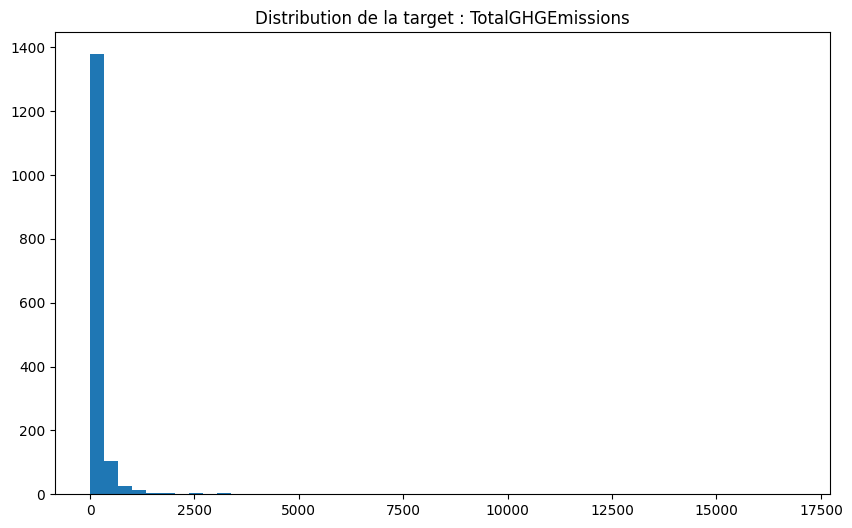

In [170]:
#distribution de la target  
plt.figure(figsize=(10,6))
plt.hist(building_consumption['TotalGHGEmissions'], bins=50)
plt.title("Distribution de la target : TotalGHGEmissions")
plt.show()

In [171]:
import numpy as np
from scipy import stats

def remove_outlier(df, column, method='IQR'):
    """
    Supprime les outliers de df[column] selon la méthode choisie.
    Retourne un NOUVEAU DataFrame filtré.
    """
    df = df.copy()  

    if method == 'IQR':
        # méthode 1 : IQR
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    elif method == 'Zscore':
        # méthode 2 : Z-score
        z = stats.zscore(df[column].astype(float)) 
        mask = np.abs(z) <= 3
        df = df[mask]

    elif method == 'quantile':
        # méthode 3 : quantiles
        lower = df[column].quantile(0.05)
        upper = df[column].quantile(0.95)

        df = df[(df[column] >= lower) & (df[column] <= upper)]

    else:
        raise ValueError("method doit être 'IQR', 'Zscore' ou 'quantile'.")

    return df


In [172]:
building_consumption = remove_outlier(
     building_consumption,
     column='TotalGHGEmissions',
     method='Zscore'
)

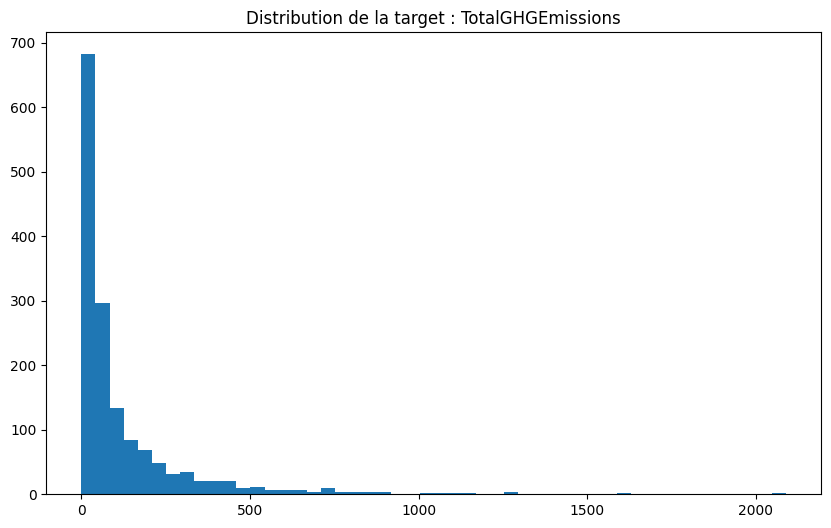

In [173]:
#distribution de la target  
plt.figure(figsize=(10,6))
plt.hist(building_consumption['TotalGHGEmissions'], bins=50)
plt.title("Distribution de la target : TotalGHGEmissions")
plt.show()

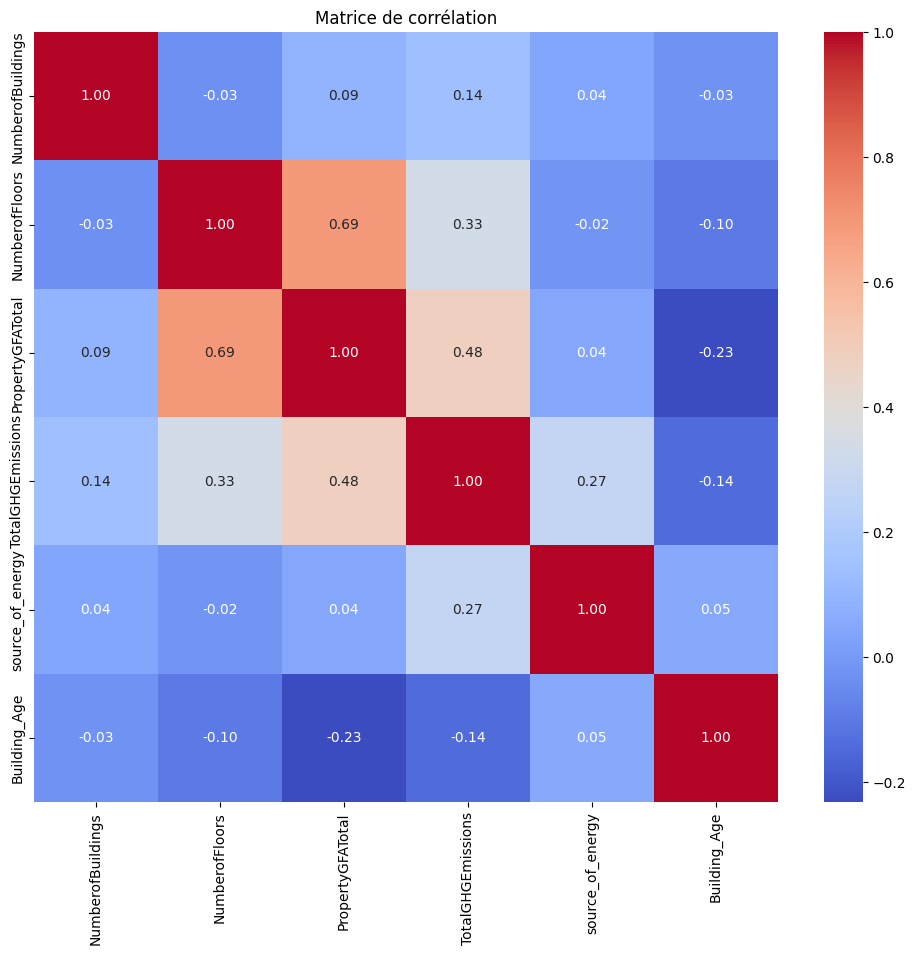

In [174]:
# matrice de corrélation colonnes numériques
numerical_columns = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'TotalGHGEmissions', 'source_of_energy', 'Building_Age']
plt.figure(figsize=(12,10))
sns.heatmap(building_consumption[numerical_columns].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

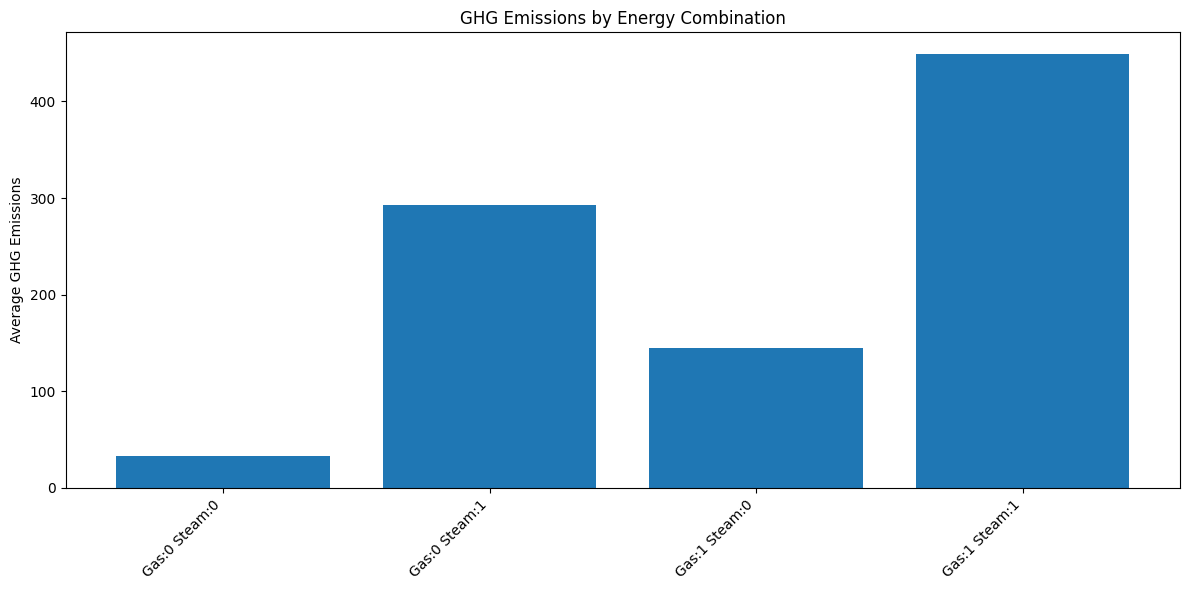

In [175]:
energy_means = (
    building_consumption
    .groupby('source_of_energy')['TotalGHGEmissions']
    .mean()
    .reset_index()
)

# Map codes to readable labels
mapping = {
    0: "Gas:0 Steam:0",
    1: "Gas:0 Steam:1",
    2: "Gas:1 Steam:0",
    3: "Gas:1 Steam:1"
}
energy_means['label'] = energy_means['source_of_energy'].map(mapping)

plt.figure(figsize=(12, 6))

plt.bar(
    x = range(len(energy_means)),
    height = energy_means['TotalGHGEmissions']
)

plt.xticks(
    range(len(energy_means)),
    energy_means['label'],
    rotation=45,
    ha='right'
)

plt.ylabel("Average GHG Emissions")
plt.title("GHG Emissions by Energy Combination")
plt.tight_layout()
plt.show()


In [176]:
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1531 entries, 0 to 3375
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1531 non-null   object 
 1   Neighborhood                     1531 non-null   object 
 2   NumberofBuildings                1531 non-null   float64
 3   NumberofFloors                   1531 non-null   int64  
 4   PropertyGFATotal                 1531 non-null   int64  
 5   ComplianceStatus                 1531 non-null   object 
 6   Outlier                          1531 non-null   object 
 7   TotalGHGEmissions                1531 non-null   float64
 8   PropertyUseRatio_Lodging         1531 non-null   float64
 9   PropertyUseRatio_PublicServices  1531 non-null   float64
 10  PropertyUseRatio_Recreation      1531 non-null   float64
 11  PropertyUseRatio_Other           1531 non-null   float64
 12  PropertyUseRatio_Educatio

In [177]:
# transformer les colonnes catégorielles en numériques avec OneHotEncoder
categorical_columns = building_consumption.select_dtypes(include=['object']).columns
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_categorical = pd.DataFrame(ohe.fit_transform(building_consumption[categorical_columns]), columns=ohe.get_feature_names_out(categorical_columns))
building_consumption = pd.concat([building_consumption.drop(columns=categorical_columns).reset_index(drop=True), encoded_categorical.reset_index(drop=True)], axis=1)

In [178]:
# separate features and target
X = building_consumption.drop(columns='TotalGHGEmissions')
y = np.log1p(building_consumption['TotalGHGEmissions'])

In [179]:
X.head()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyUseRatio_Lodging,PropertyUseRatio_PublicServices,PropertyUseRatio_Recreation,PropertyUseRatio_Other,PropertyUseRatio_Education,PropertyUseRatio_Retail,PropertyUseRatio_Office,PropertyUseRatio_Warehouse,PropertyUseRatio_Healthcare,PropertyUseRatio_Industrial,PropertyUseRatio_Parking,PropertyUseRatio_Worship,PropertyUseRatio_Restaurant,PropertyUseRatio_Laboratory,PropertyUseRatio_Grocery,source_of_energy,Building_Age,BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,BuildingType_SPS-District K-12,Neighborhood_Non-Industrial,ComplianceStatus_Non-Compliant,Outlier_High outlier,Outlier_Low outlier,Building_Age_Category_20-50,Building_Age_Category_50-80,Building_Age_Category_80+
0,1.0,12,88434,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,3,90,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,11,103566,0.809918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.145453,0.0,0.044629,0.0,0.0,2,21,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,41,956110,0.791220,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,3,48,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,10,61320,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,3,91,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,18,175580,0.703070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.387339,0.0,0.000000,0.0,0.0,2,37,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [180]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1531 entries, 0 to 1530
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   NumberofBuildings                1531 non-null   float64
 1   NumberofFloors                   1531 non-null   int64  
 2   PropertyGFATotal                 1531 non-null   int64  
 3   PropertyUseRatio_Lodging         1531 non-null   float64
 4   PropertyUseRatio_PublicServices  1531 non-null   float64
 5   PropertyUseRatio_Recreation      1531 non-null   float64
 6   PropertyUseRatio_Other           1531 non-null   float64
 7   PropertyUseRatio_Education       1531 non-null   float64
 8   PropertyUseRatio_Retail          1531 non-null   float64
 9   PropertyUseRatio_Office          1531 non-null   float64
 10  PropertyUseRatio_Warehouse       1531 non-null   float64
 11  PropertyUseRatio_Healthcare      1531 non-null   float64
 12  PropertyUseRatio_Ind

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [181]:
# CODE COMPARAISON DES MODELES
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

def model_comparaison(X, y):
    models = {
        "Dummy": DummyRegressor(strategy="mean"),
        "Linear": LinearRegression(),
        "SVR": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf"))
        ]),
        "RandomForest": RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    }

    for name, model in models.items():
        if name == "Linear":
            model = Ridge(alpha=1.0)
        scores = cross_validate(
            model,
            X, y,
            cv=5,
            scoring={
                "r2": "r2",
                "mse": "neg_mean_squared_error",
                "rmse": "neg_root_mean_squared_error",
                "mae": "neg_mean_absolute_error",
            }
        )

        print(f"\n=== {name} ===")
        print("R2  :",  scores["test_r2"].mean())
        print("MSE :", -scores["test_mse"].mean())
        print("RMSE:", -scores["test_rmse"].mean())
        print("MAE :", -scores["test_mae"].mean())

In [182]:
model_comparaison(X,y)


=== Dummy ===
R2  : -0.37189602924655385
MSE : 2.173331160964719
RMSE: 1.4633061560650218
MAE : 1.1809246972291332

=== Linear ===
R2  : 0.418189950834047
MSE : 0.9248147605335738
RMSE: 0.9573418733528711
MAE : 0.7637603779658246

=== SVR ===
R2  : 0.5049154652824472
MSE : 0.7925297742637121
RMSE: 0.8885886282505119
MAE : 0.6818937517407105

=== RandomForest ===
R2  : 0.6124607313007031
MSE : 0.6217626915019343
RMSE: 0.7877260777277052
MAE : 0.6125253181058233


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [183]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

In [184]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

def gridsearch_random_forest(X, y):
    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        bootstrap=True
    )

    param_grid = {
        "n_estimators": [300, 600],
        "max_depth": [12, 18, None],
        "min_samples_split": [5, 10],
        "min_samples_leaf": [2, 5],
        "max_features": ["sqrt", 0.6],
    }

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X, y)

    print("Best parameters :", grid.best_params_)
    print("Best CV R² score:", grid.best_score_)

    return grid.best_estimator_


In [185]:
best_model = gridsearch_random_forest(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters : {'max_depth': 18, 'max_features': 0.6, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 600}
Best CV R² score: 0.6291057801718553


In [186]:
# Récupérer l'importance des features
importances = best_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df)

                            feature  importance
2                  PropertyGFATotal    0.373273
18                 source_of_energy    0.284841
1                    NumberofFloors    0.066559
10       PropertyUseRatio_Warehouse    0.059569
9           PropertyUseRatio_Office    0.040397
19                     Building_Age    0.040309
17         PropertyUseRatio_Grocery    0.023485
13         PropertyUseRatio_Parking    0.011618
5       PropertyUseRatio_Recreation    0.011428
3          PropertyUseRatio_Lodging    0.011009
6            PropertyUseRatio_Other    0.010658
15      PropertyUseRatio_Restaurant    0.009347
8           PropertyUseRatio_Retail    0.009133
16      PropertyUseRatio_Laboratory    0.007442
27              Outlier_Low outlier    0.005356
24      Neighborhood_Non-Industrial    0.004519
25   ComplianceStatus_Non-Compliant    0.004511
20      BuildingType_NonResidential    0.003544
29      Building_Age_Category_50-80    0.003422
11      PropertyUseRatio_Healthcare    0

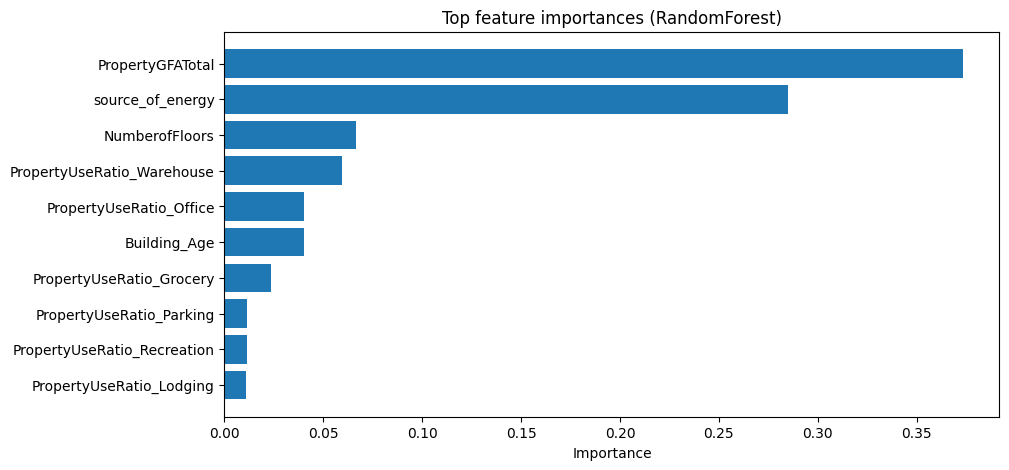

In [187]:
import matplotlib.pyplot as plt

top_n = 10

top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top feature importances (RandomForest)")
plt.show()
